In [ ]:
import os
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy.stats import gmean

# Enable inline plotting for Jupyter Notebooks
%matplotlib inline

def safe_gmean(x):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    valid_x = x.dropna()
    valid_x = valid_x[valid_x > 0]
    if valid_x.empty:
        return np.nan
    return gmean(valid_x)

def get_algorithm_labels(locations):
    """
    Takes a list of file paths and returns a list of formatted algorithm labels.
    """
    def map_single(location_string):
        filename = os.path.basename(location_string).replace('.json', '')
        clean_name = filename.replace('query-results-raw-', '')

        # Extract size suffix and base algorithm name
        if clean_name[-2:].lower() in ['-s', '-m', '-l']:
            size = clean_name[-1].lower()
            base_type = clean_name[:-2]
        else:
            return clean_name  # Fallback if no valid size suffix exists

        # Apply mapping rules
        mapping = {
            'cache': 'unindexed-cache',
            'query-cache': 'indexed-cache',
            'query-cache-estimate': 'indexed-cache-estimation'
        }

        mapped_type = mapping.get(base_type, base_type)
        return f"{mapped_type}-{size}"

    return [map_single(loc) for loc in locations]


def investigate_refinement_patterns(baseline_locations, cache_locations, custom_labels=None):
    def parse_file(filepath, is_cache=False):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                seq_element = item.get('sequenceElement', {})
                refinement_meta = seq_element.get('refinementMetadata', {})

                # Calculate depth from patternIds array
                pattern_ids = refinement_meta.get('patternIds', []) if isinstance(refinement_meta, dict) else []
                refinement_depth = len(pattern_ids)

                time_val = item.get('time')
                timestamps = item.get("timestamps", [])
                num_timestamps = len(timestamps)

                # Strict filtering
                time_first = timestamps[0] if num_timestamps > 0 else pd.NA
                time_last = timestamps[-1] if num_timestamps > 0 else pd.NA
                has_results = num_timestamps > 0

                # Pre-calculate temporal and throughput metrics per individual run
                compute_time = pd.NA
                if has_results and pd.notna(time_first) and pd.notna(time_val):
                    compute_time = max(0, time_val - time_first)

                throughput = 0.0
                if has_results and pd.notna(time_last) and time_last > 0:
                    throughput = num_timestamps / time_last

                record = {
                    'name': item.get('name'),
                    'id_int': int(item.get('id', 0)),
                    'template': seq_element.get('template', 'unknown'),
                    'refinement_depth': refinement_depth,
                    'time': time_val,
                    "time_first": time_first,
                    "compute_time": compute_time,
                    "throughput": throughput,
                    "has_results": has_results,
                    "num_timestamps": num_timestamps,
                }

                if is_cache:
                    cache_str = item.get("@comunica/persistent-cache-manager:sourceState")
                    if not cache_str:
                        cache_str = item.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

                    hit_ratio = np.nan
                    eviction_pct = np.nan

                    if cache_str:
                        try:
                            cache_stats = json.loads(cache_str)
                            hits = cache_stats.get("hits", 0)
                            misses = cache_stats.get("misses", 0)
                            evictions = cache_stats.get("evictions", 0)

                            total_req = hits + misses
                            hit_ratio = (hits / total_req) if total_req > 0 else 0.0

                            total_ops = hits + misses + evictions
                            eviction_pct = (evictions / total_ops) * 100 if total_ops > 0 else 0.0
                        except json.JSONDecodeError:
                            print(f"JSON decode error in {filepath}")

                    record['hit_ratio'] = hit_ratio
                    record['eviction_percentage'] = eviction_pct

                records.append(record)

        # Filter sequences: Keep refinements AND the initial base template preceding them
        filtered_records = []
        for i in range(len(records)):
            curr = records[i]
            if curr['refinement_depth'] > 0:
                filtered_records.append(curr)
            else:
                keep = False
                for j in range(i + 1, len(records)):
                    nxt = records[j]
                    if nxt['name'] != curr['name']:
                        break

                    if nxt['id_int'] != curr['id_int'] or nxt['template'] != curr['template']:
                        if nxt['refinement_depth'] > 0:
                            keep = True
                        break
                if keep:
                    filtered_records.append(curr)

        return pd.DataFrame(filtered_records)

    df_base_list = [parse_file(loc, is_cache=False) for loc in baseline_locations]
    if not df_base_list:
        return pd.DataFrame()
    df_base = pd.concat(df_base_list, ignore_index=True)

    # Aggregate Baseline (Median)
    df_base_agg = df_base.groupby(['name', 'id_int', 'template', 'refinement_depth']).agg(
        time_baseline=('time', 'median'),
        time_first_baseline=('time_first', 'median'),
        throughput_baseline=('throughput', 'median')
    ).reset_index()

    # Determine labels
    if custom_labels is None:
        target_labels = get_algorithm_labels(cache_locations)
    else:
        target_labels = custom_labels

    # Process Cache Data
    final_cache_dfs = []
    for cache_loc, full_label in zip(cache_locations, target_labels):
        df_cache = parse_file(cache_loc, is_cache=True)
        if df_cache.empty:
            continue

        # Extract base algorithm and size for faceting
        if full_label[-2:].lower() in ['-s', '-m', '-l']:
            cache_size = full_label[-1].upper()
            algorithm_name = full_label[:-2]
        else:
            cache_size = 'Unknown'
            algorithm_name = full_label

        # Aggregate Cache (Median for base absolute values)
        df_cache_agg = df_cache.groupby(['name', 'id_int', 'template', 'refinement_depth']).agg(
            time=('time', 'median'),
            time_first=('time_first', 'median'),
            compute_time=('compute_time', 'median'),
            throughput=('throughput', 'median'),
            hit_ratio=('hit_ratio', 'median'),
            eviction_percentage=('eviction_percentage', 'median')
        ).reset_index()

        df_merged = pd.merge(df_cache_agg, df_base_agg, on=['name', 'id_int', 'template', 'refinement_depth'], how='inner')

        # Calculate distinct speedups
        df_merged['speedup_total'] = df_merged['time_baseline'] / df_merged['time']
        df_merged['speedup_first'] = df_merged['time_first_baseline'] / df_merged['time_first']

        # Calculate throughput speedup
        df_merged['speedup_throughput'] = np.where(
            (df_merged['throughput_baseline'] > 0) & (df_merged['throughput'] > 0),
            df_merged['throughput'] / df_merged['throughput_baseline'],
            np.nan
        )

        df_merged['algorithm'] = algorithm_name
        df_merged['cache_size'] = cache_size

        final_cache_dfs.append(df_merged)

    if not final_cache_dfs:
        return pd.DataFrame()

    df_final = pd.concat(final_cache_dfs, ignore_index=True)
    df_final['cache_size'] = pd.Categorical(df_final['cache_size'], categories=['S', 'M', 'L'], ordered=True)

    return df_final


def plot_refinement_cache_metrics(df, save_path="."):
    """
    Generates inline Seaborn plots evaluating cache performance.
    Saves each plot as a PDF to the specified save_path.
    """
    if df.empty:
        print("DataFrame is empty. No plots to generate.")
        return

    if not os.path.exists(save_path):
        os.makedirs(save_path)
    # Apply LNCS specific styling to Matplotlib and Seaborn
    rc_params = {
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 14,
        "axes.titlesize": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 14,
        "figure.titlesize": 14
    }

    # Pass the dictionary to Seaborn's theme setter
    sns.set_theme(style="whitegrid", rc=rc_params)

    # sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

    # Pre-process plotting data
    plot_df = df.copy()
    plot_df['hit_ratio_pct'] = plot_df['hit_ratio'] * 100 # Align scales
    algorithm_order = sorted(plot_df['algorithm'].unique().tolist())
    colors = sns.color_palette("colorblind", n_colors=len(algorithm_order))

    # Define robust, colorblind-friendly markers and line styles
    style_markers = ["o", "s", "^", "D", "v"]
    style_lines = ["-", "--", ":", "-.", "-"]

    # ==========================================
    # Plot A: Combined Hit Ratio & Evictions
    # ==========================================
    g1 = sns.FacetGrid(plot_df, col="cache_size", height=4.5, aspect=1.1)

    def draw_combo(data, **kwargs):
        ax = plt.gca()

        # 1. Background Bars (Evictions)
        sns.barplot(
            data=data, x="refinement_depth", y="eviction_percentage",
            hue="algorithm", hue_order=algorithm_order,
            palette="colorblind", alpha=0.6, ax=ax, errorbar=None, legend=False
        )

        # 2. Foreground Lines (Hit Ratio)
        sns.pointplot(
            data=data, x="refinement_depth", y="hit_ratio_pct",
            hue="algorithm", hue_order=algorithm_order,
            palette="colorblind",
            markers=style_markers[:len(algorithm_order)],
            linestyles=style_lines[:len(algorithm_order)],
            ax=ax, errorbar=None, legend=False
        )

    g1.map_dataframe(draw_combo)

    # Combo Plot Formatting
    g1.set_axis_labels(r"Refinement Depth (0 = Base Template)", r"Percentage (\%)", fontsize=16)
    g1.set_titles(col_template="Cache Size: {col_name}", fontsize=16, fontweight='bold')

    for ax in g1.axes.flat:
        ax.set_ylim(-2, 105) # Add minor padding below 0
        ax.yaxis.set_major_formatter(ticker.PercentFormatter())

    # Build Custom Legend
    custom_handles = [
        mlines.Line2D([], [], color='black', marker='o', label='Hit Ratio (Line)'),
        mpatches.Patch(color='gray', alpha=0.35, label='Evictions (Bar)')
    ]
    custom_labels = ['Hit Ratio (Line)', 'Evictions (Bar)']

    for i, alg in enumerate(algorithm_order):
        c = colors[i]
        m = style_markers[i % len(style_markers)]
        ls = style_lines[i % len(style_lines)]

        custom_handles.append(mlines.Line2D([], [], color=c, marker=m, linestyle=ls, markersize=7))
        custom_labels.append(alg)

    # Place legend horizontally above the plots, removing the suptitle
    g1.figure.legend(handles=custom_handles, labels=custom_labels,
                     loc='lower center', bbox_to_anchor=(0.5, 1.05),
                     ncol=3, frameon=True, edgecolor='black')

    g1.figure.tight_layout()

    combo_path = os.path.join(save_path, "combined_cache_efficiency.pdf")
    g1.savefig(combo_path, bbox_inches='tight')
    print(f"Saved: {combo_path}")
    plt.show()


def plot_temporal_throughput_line(df, save_path="."):
    """
    Generates a stylized point plot showing total time and throughput speedups
    across refinement depths, separated by cache size.
    """
    if df.empty:
        print("DataFrame is empty.")
        return

    if not os.path.exists(save_path):
        os.makedirs(save_path)

    # Data cleaning
    df_clean = df.copy()
    for col in ['speedup_total', 'speedup_throughput']:
        df_clean[col] = pd.to_numeric(df_clean[col]).fillna(0)

    # Melt data for Seaborn (long format)
    melted_df = df_clean.melt(
        id_vars=['cache_size', 'algorithm', 'refinement_depth'],
        value_vars=['speedup_total', 'speedup_throughput'],
        var_name='Metric',
        value_name='Speedup'
    )

    melted_df['Metric'] = melted_df['Metric'].replace({
        'speedup_total': 'Total Time',
        'speedup_throughput': 'Throughput'
    })

    rc_params = {
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 14,
        "figure.titlesize": 14
    }

    # Pass the dictionary to Seaborn's theme setter
    sns.set_theme(style="whitegrid", rc=rc_params)

    algorithm_order = sorted(df_clean['algorithm'].unique().tolist())
    cache_order = sorted(df_clean['cache_size'].unique())[::-1]
    colors = sns.color_palette("colorblind", n_colors=len(algorithm_order))

    style_markers = ["o", "s", "^", "D", "v"]

    g = sns.FacetGrid(melted_df, col="cache_size", col_order=cache_order, height=4.5, aspect=1.1)

    def draw_speedup_lines(data, **kwargs):
        ax = plt.gca()

        # Total Time (Solid lines)
        sns.pointplot(
            data=data[data['Metric'] == 'Total Time'],
            x="refinement_depth", y="Speedup",
            hue="algorithm", hue_order=algorithm_order,
            palette="colorblind",
            markers=style_markers[:len(algorithm_order)],
            linestyles=["-"] * len(algorithm_order),
            estimator=safe_gmean,
            ax=ax, errorbar=None, legend=False
        )

        # Throughput (Dashed lines)
        sns.pointplot(
            data=data[data['Metric'] == 'Throughput'],
            x="refinement_depth", y="Speedup",
            hue="algorithm", hue_order=algorithm_order,
            palette="colorblind",
            markers=style_markers[:len(algorithm_order)],
            linestyles=["--"] * len(algorithm_order),
            estimator=safe_gmean,
            ax=ax, errorbar=None, legend=False
        )

    g.map_dataframe(draw_speedup_lines)

    g.set_axis_labels("Refinement Depth (0 = Base Template)", "Geometric Mean Speedup (vs No Cache)", fontsize=16)
    g.set_titles(col_template="Cache Size: {col_name}", fontsize=16, fontweight='bold')

    for ax in g.axes.flat:
        ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)

        ylim = ax.get_ylim()
        new_top = max(ylim[1], 2.5)
        ax.set_ylim(bottom=0, top=new_top)

        ylim = ax.get_ylim()
        ticks = ax.get_yticks()

        if len(ticks) > 1:
            step = ticks[1] - ticks[0]
            if step > 0:
                min_tick = 1.0 - np.ceil((1.0 - ylim[0]) / step) * step
                max_tick = 1.0 + np.ceil((ylim[1] - 1.0) / step) * step
                new_ticks = np.arange(min_tick, max_tick + step / 2, step)
                new_ticks = new_ticks[new_ticks >= 0]
                ax.set_yticks(new_ticks)

        ax.set_ylim(bottom=0, top=ylim[1])
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:g}x'))

    # Build Custom Legend
    custom_handles = [
        mlines.Line2D([], [], color='black', linestyle='-', label='Total Time (Solid)'),
        mlines.Line2D([], [], color='black', linestyle='--', label='Throughput (Dashed)')
    ]
    custom_labels = ['Total Time (Solid)', 'Throughput (Dashed)']

    for i, alg in enumerate(algorithm_order):
        c = colors[i]
        m = style_markers[i % len(style_markers)]
        custom_handles.append(mlines.Line2D([], [], color=c, marker=m, linestyle='', markersize=8))
        custom_labels.append(alg)

    # Place legend horizontally above the plots, removing the suptitle
    g.figure.legend(handles=custom_handles, labels=custom_labels,
                    loc='lower center', bbox_to_anchor=(0.5, 1.05),
                    ncol=3, frameon=True, edgecolor='black')

    g.figure.tight_layout()

    save_target = os.path.join(save_path, "temporal_throughput_line.pdf")
    plt.savefig(save_target, bbox_inches='tight')
    print(f"Saved: {save_target}")
    plt.show()

# Execution block
if __name__ == "__main__":
    raw_data_cache_s = os.path.join("..", "data", "query-results-raw-cache-s.json")
    raw_data_cache_m = os.path.join("..", "data", "query-results-raw-cache-m.json")
    raw_data_cache_l = os.path.join("..", "data", "query-results-raw-cache-l.json")

    raw_data_query_cache_s = os.path.join("..", "data", "query-results-raw-query-cache-s.json")
    raw_data_query_cache_m = os.path.join("..", "data", "query-results-raw-query-cache-m.json")
    raw_data_query_cache_l = os.path.join("..", "data", "query-results-raw-query-cache-l.json")

    raw_data_query_cache_estimate_s = os.path.join("..", "data", "query-results-raw-query-cache-estimate-s.json")
    raw_data_query_cache_estimate_m = os.path.join("..", "data", "query-results-raw-query-cache-estimate-m.json")
    raw_data_query_cache_estimate_l = os.path.join("..", "data", "query-results-raw-query-cache-estimate-l.json")

    all_caches = [
        raw_data_cache_s, raw_data_cache_m, raw_data_cache_l,
        raw_data_query_cache_s, raw_data_query_cache_m, raw_data_query_cache_l,
        raw_data_query_cache_estimate_s, raw_data_query_cache_estimate_m, raw_data_query_cache_estimate_l
    ]

    location_default = [ os.path.join("..", "data", "query-results-raw-default.json") ]

    df_final = investigate_refinement_patterns(location_default, all_caches)
    plot_refinement_cache_metrics(df_final, "../output/refinement_figures")
    plot_temporal_throughput_line(df_final, "../output/refinement_figures")

In [ ]:
import os
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Enable inline plotting for Jupyter Notebooks
%matplotlib inline

# Dummy map for pattern IDs to structural types
# Update this dictionary with your actual pattern ID mappings
PATTERN_TYPE_MAP = {
    0: "Add Filter",
    1: "Add Join",
    2: "Add Optional",
    3: "Add Union",
    4: "Change Limit/Offset",
    5: "Change Order"
}

def investigate_refinement_types(baseline_locations, cache_locations):
    def parse_file(filepath, is_cache=False):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                seq_element = item.get('sequenceElement', {})
                refinement_meta = seq_element.get('refinementMetadata', {})

                # Extract the latest pattern ID to determine the current refinement type
                pattern_ids = refinement_meta.get('patternIds', []) if isinstance(refinement_meta, dict) else []
                refinement_depth = len(pattern_ids)

                if refinement_depth > 0:
                    latest_pattern_id = pattern_ids[-1]
                    ref_type = PATTERN_TYPE_MAP.get(latest_pattern_id, f"Type {latest_pattern_id}")
                else:
                    ref_type = "Base Template"

                record = {
                    'name': item.get('name'),
                    'id_int': int(item.get('id', 0)),
                    'template': seq_element.get('template', 'unknown'),
                    'refinement_depth': refinement_depth,
                    'refinement_type': ref_type,
                    'time': item.get('time')
                }

                if is_cache:
                    cache_str = item.get("@comunica/persistent-cache-manager:sourceState")
                    if not cache_str:
                        cache_str = item.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

                    hit_ratio = np.nan
                    eviction_pct = np.nan

                    if cache_str:
                        try:
                            cache_stats = json.loads(cache_str)
                            hits = cache_stats.get("hits", 0)
                            misses = cache_stats.get("misses", 0)
                            evictions = cache_stats.get("evictions", 0)

                            total_req = hits + misses
                            hit_ratio = (hits / total_req) if total_req > 0 else 0.0

                            total_ops = hits + misses + evictions
                            eviction_pct = (evictions / total_ops) * 100 if total_ops > 0 else 0.0
                        except json.JSONDecodeError:
                            print(f"JSON decode error in {filepath}")

                    record['hit_ratio'] = hit_ratio
                    record['eviction_percentage'] = eviction_pct

                records.append(record)

        # Filter sequences to maintain valid comparison chains
        filtered_records = []
        for i in range(len(records)):
            curr = records[i]
            if curr['refinement_depth'] > 0:
                filtered_records.append(curr)
            else:
                keep = False
                for j in range(i + 1, len(records)):
                    nxt = records[j]
                    if nxt['name'] != curr['name']:
                        break

                    if nxt['id_int'] != curr['id_int'] or nxt['template'] != curr['template']:
                        if nxt['refinement_depth'] > 0:
                            keep = True
                        break
                if keep:
                    filtered_records.append(curr)

        return pd.DataFrame(filtered_records)

    # 1. Process Baseline Data
    df_base_list = [parse_file(loc, is_cache=False) for loc in baseline_locations]
    if not df_base_list:
        return pd.DataFrame()
    df_base = pd.concat(df_base_list, ignore_index=True)

    df_base_agg = df_base.groupby(['name', 'id_int', 'template', 'refinement_type'])['time'].median().reset_index()
    df_base_agg.rename(columns={'time': 'time_baseline'}, inplace=True)

    # 2. Process Cache Data
    final_cache_dfs = []
    for cache_loc in cache_locations:
        raw_filename = os.path.basename(cache_loc).replace('.json', '')

        clean_name = raw_filename.replace('query-results-raw-', '')
        if clean_name[-2:] in ['-s', '-m', '-l', '-S', '-M', '-L']:
            cache_size = clean_name[-1].upper()
            algorithm_name = clean_name[:-2]
        else:
            cache_size = 'Unknown'
            algorithm_name = clean_name

        df_cache = parse_file(cache_loc, is_cache=True)
        if df_cache.empty:
            continue

        df_cache_agg = df_cache.groupby(['name', 'id_int', 'template', 'refinement_type']).agg({
            'time': 'median',
            'hit_ratio': 'median',
            'eviction_percentage': 'median'
        }).reset_index()

        df_merged = pd.merge(df_cache_agg, df_base_agg, on=['name', 'id_int', 'template', 'refinement_type'], how='inner')
        df_merged['speedup'] = df_merged['time_baseline'] / df_merged['time']

        df_merged['algorithm'] = algorithm_name
        df_merged['cache_size'] = cache_size

        final_cache_dfs.append(df_merged)

    if not final_cache_dfs:
        return pd.DataFrame()

    df_final = pd.concat(final_cache_dfs, ignore_index=True)
    df_final['cache_size'] = pd.Categorical(df_final['cache_size'], categories=['S', 'M', 'L'], ordered=True)

    return df_final


def plot_refinement_types(df):
    """
    Generates inline Seaborn bar plots evaluating cache performance
    across refinement types, faceted by Cache Size.
    """
    if df.empty:
        print("DataFrame is empty. No plots to generate.")
        return

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    algorithm_order = sorted(df['algorithm'].unique().tolist())

    # Exclude Base Template from plots to focus on the impact of the specific refinement patterns
    df_plot = df[df['refinement_type'] != "Base Template"]

    # Plot A: Hit Ratio by Type
    g1 = sns.catplot(
        data=df_plot,
        x="refinement_type",
        y="hit_ratio",
        hue="algorithm",
        col="cache_size",
        hue_order=algorithm_order,
        kind="bar",
        height=4.5,
        aspect=1.2,
        palette="viridis",
        errorbar=None
    )
    g1.set_axis_labels("Refinement Type", "Median Hit Ratio")
    g1.set_titles("Cache Size: {col_name}")
    g1.set_xticklabels(rotation=45, ha="right")
    plt.subplots_adjust(top=0.85)
    g1.fig.suptitle("Impact of Refinement Pattern Type on Cache Hit Ratio")
    plt.show()

    # Plot B: Evictions by Type
    g2 = sns.catplot(
        data=df_plot,
        x="refinement_type",
        y="eviction_percentage",
        hue="algorithm",
        col="cache_size",
        hue_order=algorithm_order,
        kind="bar",
        height=4.5,
        aspect=1.2,
        palette="flare",
        errorbar=None
    )
    g2.set_axis_labels("Refinement Type", "Median Eviction Percentage (%)")
    g2.set_titles("Cache Size: {col_name}")
    g2.set_xticklabels(rotation=45, ha="right")
    plt.subplots_adjust(top=0.85)
    g2.fig.suptitle("Cache Thrashing Driven by Refinement Pattern Type")
    plt.show()

    # Plot C: Speedup by Type
    g3 = sns.catplot(
        data=df_plot,
        x="refinement_type",
        y="speedup",
        hue="algorithm",
        col="cache_size",
        hue_order=algorithm_order,
        kind="bar",
        height=4.5,
        aspect=1.2,
        palette="mako",
        errorbar=None
    )
    g3.set_axis_labels("Refinement Type", "Median Speedup (vs Uncached)")
    g3.set_titles("Cache Size: {col_name}")
    g3.set_xticklabels(rotation=45, ha="right")
    g3.refline(y=1.0, color="red", linestyle="--", label="Baseline (1x)")
    plt.subplots_adjust(top=0.85)
    g3.fig.suptitle("Execution Speedup per Refinement Pattern Type")
    plt.show()

# Execution block
if __name__ == "__main__":
    # Assuming file location lists (all_caches, location_default) are defined as before
    # df_final_types = investigate_refinement_types(location_default, all_caches)
    # plot_refinement_types(df_final_types)
    pass

In [14]:
from load_raw_data import yield_sequence_topologies
# Python artifact mapping refinement patterns to their underlying chokepoints for regression analysis
import json
import pandas as pd

# Python artifact mapping refinement patterns to their underlying chokepoints for regression analysis

refinements_mapping = {
    "interactive-discover-1": {
        0: ['P.4.a', 'T.1.a', 'T.3.a'],
        1: ['P.4.r', 'T.1.r', 'T.3.r'],
        2: ['P.3.a'],
        3: ['P.3.r'],
        4: ['P.3.r'],
        5: ['P.1.a'],
        6: ['P.1.r'],
        7: ['T.2.a'],
        8: ['T.2.r'],
    },
    "interactive-discover-2": {
        0: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        1: ['P.2.r', 'P.4.r', 'T.1.r', 'T.3.r'],
        2: ['P.3.r', 'T.1.r', 'T.4.r'],
        3: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        4: ['P.4.a'],
        5: ['P.4.r'],
        6: ['P.1.a'],
        7: ['P.1.r'],
        8: ['P.1.a', 'P.2.a'],
        9: ['P.1.r', 'P.2.r'],
        10: ['T.2.a'],
        11: ['T.2.r'],
    },
    "interactive-discover-3": {
        0: ['P.1.a', 'T.2.a'],
        1: ['P.4.a'],
        2: ['T.2.r'],
        3: ['P.4.r'],
        4: ['T.4.a'],
        5: ['T.4.r'],
        7: ['T.1.a', 'P.3.a'],
        8: ['P.4.a'],
        9: ['T.1.r', 'P.3.r'],
        10: ['P.4.r'],
        11: ['P.1.a', 'P.2.a'],
        12: ['P.1.a', 'P.2.a'],
        13: ['P.1.r'],
        14: ['P.1.r'],
        15: ['T.2.a'],
        16: ['T.2.r'],
    },
    "interactive-discover-4": {
        0: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        1: ['P.2.r', 'P.4.r', 'T.1.r', 'T.3.r'],
        3: ['P.2.a', 'P.4.a', 'T.4.a'],
        4: ['P.2.r', 'P.4.r', 'T.4.r'],
        6: ['P.3.a', 'T.1.a', 'T.3.a'],
        7: ['P.3.r', 'T.1.r', 'T.3.r'],
        8: ['P.1.a'],
        9: ['P.1.r'],
        10: ['T.2.r'],
        11: ['T.2.a'],
    },
    "interactive-discover-5": {
        1: ['P.3.a', 'T.4.a'],
        2: ['P.3.r', 'T.4.r'],
        3: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        4: ['P.2.r', 'P.4.r', 'T.1.r', 'T.3.r'],
        5: ['T.1.a', 'P.3.a'],
        6: ['T.1.r', 'P.3.r'],
        7: ['P.1.a'],
        8: ['P.1.r'],
        9: ['T.2.a'],
        10: ['T.2.r'],
    },
    "interactive-discover-6": {
        0: ['T.1.a', 'P.4.a'],
        1: ['T.1.r', 'P.4.r'],
        2: ['P.2.a', 'T.1.a', 'T.3.a'],
        3: ['P.2.r', 'T.1.r', 'T.3.r'],
        4: ['P.1.a'],
        5: ['P.1.r'],
        6: ['T.2.a'],
        7: ['T.2.r'],
    },
    "interactive-discover-7": {
        0: ['P.3.a'],
        1: ['P.3.r'],
        2: ['P.2.a', 'P.4.a'],
        3: ['P.2.r', 'P.4.r'],
        4: ['P.1.a'],
        5: ['P.1.r'],
        6: ['P.1.a'],
        7: ['P.1.r'],
        8: ['T.2.a'],
        9: ['T.2.r'],
    },
    "interactive-discover-8": {
        0: ['T.1.a', 'P.4.a', 'T.3.a'],
        1: ['T.1.r', 'P.4.r', 'T.3.r'],
        2: ['T.3.a', 'P.3.a'],
        3: ['T.3.r', 'P.3.r'],
        4: ['P.2.a', 'P.3.a', 'T.1.a', 'T.3.a'],
        5: ['P.2.r', 'P.3.r', 'T.1.r', 'T.3.r'],
        6: ['P.1.a'],
        7: ['P.1.r'],
        8: ['T.2.a'],
        9: ['T.2.r'],
    },
    "interactive-short-1": {
        0: ['T.1.a', 'T.3.a', 'P.4.a'],
        1: ['T.1.r', 'T.3.r', 'P.4.r'],
        2: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a', 'T.4.a'],
        3: ['P.2.r', 'P.4.r', 'T.1.r', 'T.3.r', 'T.4.r'],
        4: ['T.2.a'],
        5: ['T.2.r'],
    },
    "interactive-short-2": {
        0: ['T.1.a', 'T.3.a', 'P.4.a'],
        1: ['T.1.r', 'T.3.r', 'P.4.r'],
        2: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        3: ['P.2.r', 'P.4.r', 'T.1.r', 'T.3.r'],
        4: ['P.1.a'],
        5: ['P.1.r'],
        6: ['T.2.a'],
        7: ['T.2.r'],
    },
    "interactive-short-3": {
        0: ['P.4.a'],
        1: ['P.4.r'],
        2: ['P.4.a'],
        3: ['P.4.r'],
        4: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        5: ['P.2.r', 'P.4.r', 'T.1.r', 'T.3.r'],
        6: ['T.2.a'],
        7: ['T.2.r'],
    },
    "interactive-short-4": {
        0: ['P.3.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        1: ['P.3.r', 'P.4.r', 'T.1.r', 'T.3.r'],
        2: ['P.4.a', 'T.1.a', 'T.3.a'],
        3: ['P.4.r', 'T.1.r', 'T.3.r'],
        4: ['P.4.a', 'P.2.a', 'T.1.a', 'T.3.a'],
        5: ['P.4.r', 'P.2.r', 'T.1.r', 'T.3.r'],
        6: ['P.1.a'],
        7: ['P.1.r'],
        8: ['T.2.a'],
        9: ['T.2.r'],
    },
    "interactive-short-5": {
        0: ['P.3.a', 'T.4.a'],
        1: ['P.3.r', 'T.4.r'],
        2: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        3: ['P.2.r', 'P.4.r', 'T.1.r', 'T.3.r', 'T.4.r'],
        4: ['P.4.a'],
        5: ['P.4.r'],
        6: ['T.2.a'],
        7: ['T.2.r'],
    },
    "interactive-short-6": {
        0: ['T.1.a', 'P.4.a'],
        1: ['T.1.r', 'P.4.r'],
        2: ['T.1.a', 'T.3.a', 'P.3.a'],
        3: ['T.1.r', 'T.3.r', 'P.3.r'],
        4: ['P.2.a', 'P.4.a'],
        5: ['P.2.r', 'P.4.r'],
        6: ['T.2.a'],
        7: ['T.2.r'],
    },
    "interactive-short-7": {
        0: ['P.3.a', 'T.1.a'],
        1: ['P.3.r'],
        2: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        3: ['P.2.r', 'P.4.r', 'T.1.r', 'T.3.r'],
        6: ['T.2.a'],
        7: ['T.2.r'],
    },
}

def get_cache_hit_rate(record, record_topology):
    """
    Calculates the cache hit rate from the sourceStateQuerySource string.
    Returns a float between 0.0 and 1.0. Returns 0.0 if no accesses occurred.
    """
    cache_data_str = record.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

    if not cache_data_str:
        return 0.0

    try:
        cache_stats = json.loads(cache_data_str)
        hits = cache_stats.get("hits", 0)
        misses = cache_stats.get("misses", 0)
        total_accesses = hits + misses

        if total_accesses == 0:
            return 0.0

        return hits / total_accesses
    except json.JSONDecodeError:
        print(f"Warning: Could not parse cache data for sequence {record.get('name')}, step {record.get('id')}")
        return 0.0

def get_execution_time(record, record_topology):
    """
    Extracts the execution time in milliseconds.
    """
    return float(record.get("time", 0.0))

def get_unique_sources(record, record_topology):
    """
    Extracts the count of unique sources from the topology.
    """
    if not record_topology:
        return 0
    node_dict = record_topology.get("indexToNodeDict", {})
    return len(node_dict)

def get_dependent_variable(record, record_topology):
    """
    STUB: Extract the target metric for your regression.
    e.g., parse the cache hits from "@comunica/persistent-cache-manager:sourceStateQuerySource"
    or calculate Jaccard overlap / unique sources.
    """
    return 0.0

def get_new_data_sources(record):
    pass

def read_topologies(sparql_dir, topology_dir, max_sequences = None):
    mapping = yield_sequence_topologies(sparql_dir, topology_dir, max_sequences)
    return mapping


import json
import pandas as pd

def is_topology_exhausted(record, current_topology_state) -> bool:
    """
    Determine if the generator needs to advance.
    """
    if current_topology_state is None:
        return True

    if record.get("name") != current_topology_state[0]:
        return True

    return False

def obtain_topology(record, generator, current_topology_state, rep_index):
    """
    Evaluates the topology state, steps through the generator if needed,
    and extracts the topology for the specific repetition.
    """
    if is_topology_exhausted(record, current_topology_state):
        try:
            current_topology_state = next(generator)
        except StopIteration:
            raise StopIteration(f"Warning: Topology generator exhausted before record {record.get('name')} step {record.get('id')}.")

    sequence_element_id = int(record.get('id'))

    # Retrieve the list of topologies for all repetitions of this query
    topologies_list = current_topology_state[1].get("sequence")[sequence_element_id].get('topologies')

    # Extract the specific repetition topology using the tracked index
    if topologies_list and rep_index < len(topologies_list):
        rep_specific_topology = topologies_list[rep_index]
    else:
        raise IndexError(f"Warning: Missing topology for {record.get('name')} step {sequence_element_id} rep {rep_index}")
        rep_specific_topology = None

    return current_topology_state, rep_specific_topology

def get_source_set(record_topology):
    """
    Extracts a set of unique source identifiers from the topology.
    """
    if not record_topology:
        return set()
    node_dict = record_topology.get("indexToNodeDict", {})

    # Assuming the values in node_dict contain the source URL or a unique identifier.
    # We cast to string to ensure they are hashable in a Python set.
    return set(str(v) for v in node_dict.values())

def build_regression_observations(file_path, mapping, topology_generator):
    with open(file_path, 'r') as f:
        data = json.load(f)

    data.sort(key=lambda x: (x.get('name', ''), int(x.get('id', 0))))

    observations = []
    current_sequence = None
    current_topology_state = None

    rep_tracker = {}
    previous_metrics = {}
    cumulative_sources = {}

    for record in data:
        seq_name = record.get("name")
        step_id = int(record.get("id"))

        track_key = (seq_name, step_id)
        rep_index = rep_tracker.get(track_key, 0)
        rep_tracker[track_key] = rep_index + 1

        current_topology_state, record_topology = obtain_topology(
            record, topology_generator, current_topology_state, rep_index
        )

        curr_hit_rate = get_cache_hit_rate(record, record_topology)
        curr_time = get_execution_time(record, record_topology)
        curr_source_set = get_source_set(record_topology)

        # Handle sequence transitions
        if seq_name != current_sequence:
            current_sequence = seq_name
            previous_metrics.clear()
            cumulative_sources.clear()

        # Establish baseline for new repetitions
        if rep_index not in previous_metrics:
            previous_metrics[rep_index] = {
                'hit_rate': curr_hit_rate,
                'time': curr_time,
                'source_set': curr_source_set # Store the actual set
            }
            cumulative_sources[rep_index] = set(curr_source_set)
            continue

        # 1. Calculate Standard Deltas
        delta_hit_rate = curr_hit_rate - previous_metrics[rep_index]['hit_rate']
        delta_time = curr_time - previous_metrics[rep_index]['time']

        # 2. Calculate Effective Network Flux
        prev_source_set = previous_metrics[rep_index]['source_set']

        # Penalty: Sources we have NEVER seen before in this sequence
        novel_sources = curr_source_set - cumulative_sources[rep_index]

        # Savings: Sources we pinged in the LAST step, but bypassed in this step
        dropped_sources = prev_source_set - curr_source_set

        # The true operational delta (Penalty - Savings)
        delta_sources = len(novel_sources) - len(dropped_sources)

        baseline_sources_count = len(cumulative_sources[rep_index])

        applied_codes = []
        seq_element = record.get("sequenceElement", {})
        template = seq_element.get("template")
        ref_metadata = seq_element.get("refinementMetadata")

        if ref_metadata and "patternIds" in ref_metadata:
            for pid in ref_metadata["patternIds"]:
                if template in mapping and pid in mapping[template]:
                    applied_codes.extend(mapping[template][pid])
                else:
                    print(f"Warning: No mapping found for {template} -> Pattern {pid}")

        observations.append({
            "Sequence_ID": seq_name,
            "Step_ID": step_id,
            "Repetition_Index": rep_index,
            "Applied_Refinement_Patterns": applied_codes,
            "Baseline_Hit_Rate": previous_metrics[rep_index]['hit_rate'],
            "Baseline_Time": previous_metrics[rep_index]['time'],
            "Baseline_Sources": baseline_sources_count,
            "Delta_Hit_Rate": delta_hit_rate,
            "Delta_Time": delta_time,
            "Delta_Sources": delta_sources,
        })

        # Update baselines for the next step
        previous_metrics[rep_index] = {
            'hit_rate': curr_hit_rate,
            'time': curr_time,
            'source_set': curr_source_set
        }
        cumulative_sources[rep_index].update(curr_source_set)

    # Convert master list to a DataFrame
    df_master = pd.DataFrame(observations)
    base_cols = ["Sequence_ID", "Step_ID", "Repetition_Index", "Applied_Refinement_Patterns"]

    df_hit_rate = df_master[base_cols + ["Delta_Hit_Rate", "Baseline_Hit_Rate"]].rename(
        columns={"Delta_Hit_Rate": "Delta_Y", "Baseline_Hit_Rate": "Baseline_Y"}
    )

    df_time = df_master[base_cols + ["Delta_Time", "Baseline_Time"]].rename(
        columns={"Delta_Time": "Delta_Y", "Baseline_Time": "Baseline_Y"}
    )
    df_time["Delta_Y"] = np.sign(df_time["Delta_Y"]) * np.log1p(np.abs(df_time["Delta_Y"]))
    df_time["Baseline_Y"] = np.log1p(df_time["Baseline_Y"])

    df_sources = df_master[base_cols + ["Delta_Sources", "Baseline_Sources"]].rename(
        columns={"Delta_Sources": "Delta_Y", "Baseline_Sources": "Baseline_Y"}
    )

    # REVERT TO SIGNED LOG1P: Because delta_sources can now be negative again
    df_sources["Delta_Y"] = np.sign(df_sources["Delta_Y"]) * np.log1p(np.abs(df_sources["Delta_Y"]))
    df_sources["Baseline_Y"] = np.log1p(df_sources["Baseline_Y"])

    return df_hit_rate, df_time, df_sources
# topologies = read_topologies(
#     "../data/refinement/out-queries",
#     "../data/refinement/output-topology-tracking-refinement-s",
# )
#
# df_hr, df_t, df_src = build_regression_observations('../data/refinement/query-results-raw-refinement-s.json', refinements_mapping, topologies)

# df_observations = build_regression_observations('../data/refinement/query-results-raw-refinement-l.json', refinements_mapping)

#
# print(df_observations.head())

In [24]:
from scipy import stats
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.preprocessing import MultiLabelBinarizer
from matplotlib import pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler

def standardize_target(df, target_col="Delta_Y"):
    """
    Standardizes the target column to have a mean of 0 and a standard deviation of 1.
    This enables cross-model comparison of effect sizes.
    """
    # Create a copy to avoid SettingWithCopyWarning
    df_standardized = df.copy()
    scaler = StandardScaler()

    # Standardize the target variable
    df_standardized[target_col] = scaler.fit_transform(df_standardized[[target_col]])

    return df_standardized

def run_mixed_effects_model(df, target_col="Delta_Y", alpha=0.0, include_interactions=False, include_quadratic=False):
    """
    One-hot encodes the refinement patterns and fits a Linear Mixed-Effects Model
    with a forced zero intercept.
    Optionally includes baseline interaction effects and a quadratic baseline term.
    Applies L1 regularization if alpha > 0.
    """
    mlb = MultiLabelBinarizer()
    encoded_matrix = mlb.fit_transform(df["Applied_Refinement_Patterns"])

    # Extract class names and sanitize them for statsmodels (replace '.' with '_')
    sanitized_cols = [str(cls).replace('.', '_') for cls in mlb.classes_]

    # Create a DataFrame from the binary matrix
    df_encoded = pd.DataFrame(encoded_matrix, columns=sanitized_cols, index=df.index)

    # Combine the target variable, random effect group, and encoded features
    df_model = pd.concat([df[["Sequence_ID", "Baseline_Y", target_col]], df_encoded], axis=1)

    # Calculate and append quadratic term if requested
    if include_quadratic:
        df_model["Baseline_Y_Squared"] = df_model["Baseline_Y"] ** 2

    # Construct the Formula
    features_string = " + ".join(sanitized_cols)

    # Determine base terms
    base_terms = "Baseline_Y_Squared + Baseline_Y" if include_quadratic else "Baseline_Y"

    if include_interactions:
        # Baseline_Y * (...) expands to main effects for the baseline, patterns, and their interactions
        formula = f"{target_col} ~ {base_terms} + Baseline_Y:({features_string}) + {features_string} - 1"
    else:
        formula = f"{target_col} ~ {base_terms} + {features_string} - 1"

    print(f"Fitting model with formula: {formula}\n")
    try:
        model = smf.mixedlm(formula, df_model, groups=df_model["Sequence_ID"])

        # Apply L1 penalty if alpha is specified.
        if alpha > 0:
            print(f"Applying L1 regularization (alpha={alpha})...")
            # method='l1' forces the Lasso penalty.
            result = model.fit_regularized(method='l1', alpha=alpha)
        else:
            result = model.fit(method='powell')

        print(result.summary())
        return result, df_model

    except Exception as e:
        print(f"Model fitting failed: {e}")
        return None, df_model

def evaluate_mixed_model(result, df_model, target_col="Delta_Y"):
    """
    Calculates goodness of fit and diagnostic metrics for a statsmodels MixedLM result.
    """
    if result is None:
        print("Invalid model result.")
        return

    print("=== Mixed-Effects Model Diagnostics ===")

    # Variance of the Fixed Effects (predicted values using ONLY fixed parameters)
    # result.predict() by default uses only the fixed effects in statsmodels
    fixed_predictions = result.predict(df_model)
    var_fixed = np.var(fixed_predictions, ddof=1)

    # Variance of the Random Effects (Sequence baseline)
    # result.cov_re gives the covariance matrix of random effects; [0,0] is the intercept variance
    var_random = result.cov_re.iloc[0, 0]

    # Variance of the Residuals (system noise)
    var_residual = result.scale

    total_variance = var_fixed + var_random + var_residual

    # 2. Nakagawa's Pseudo-R^2
    marginal_r2 = var_fixed / total_variance
    conditional_r2 = (var_fixed + var_random) / total_variance

    print(f"Marginal R^2 (Refinements only):   {marginal_r2:.4f}")
    print(f"Conditional R^2 (Full model):      {conditional_r2:.4f}")

    # 3. Intraclass Correlation Coefficient (ICC)
    # Measures the proportion of variance driven by the sequence grouping
    icc = var_random / (var_random + var_residual)
    print(f"Intraclass Correlation (ICC):      {icc:.4f}")

    return {
        "Marginal_R2": marginal_r2,
        "Conditional_R2": conditional_r2,
        "ICC": icc,
    }

def plot_residuals(result):
    """
    Plots residual diagnostics to check model assumptions.
    """
    residuals = result.resid
    fitted = result.fittedvalues

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Homoscedasticity Check (Residuals vs Fitted)
    axes[0].scatter(fitted, residuals, alpha=0.5, edgecolors='k')
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_title('Residuals vs Fitted Values')
    axes[0].set_xlabel('Fitted Values')
    axes[0].set_ylabel('Residuals')

    # Normality Check (Q-Q Plot)
    stats.probplot(residuals, dist="norm", plot=axes[1])
    axes[1].set_title('Q-Q Plot of Residuals')

    plt.tight_layout()
    plt.show()


def generate_summary_table(result, metrics):
    """
    Extracts fixed effects, p-values, and confidence intervals into a formatted table,
    and appends model diagnostics.
    """
    # Extract fixed effects summary
    summary_df = pd.DataFrame({
        "Coefficient": result.fe_params,
        "Std.Error": result.bse[result.fe_params.index],
        "z-value": result.tvalues[result.fe_params.index],
        "P>|z|": result.pvalues[result.fe_params.index],
        "[0.025": result.conf_int()[0][result.fe_params.index],
        "0.975]": result.conf_int()[1][result.fe_params.index]
    })

    # Round values for readability
    summary_df = summary_df.round(4)

    # Format p-values to indicate high significance
    summary_df["P>|z|"] = summary_df["P>|z|"].apply(
        lambda x: "<0.001" if x < 0.001 else f"{x:.4f}"
    )

    print("=== Fixed Effects Summary ===")
    print(summary_df.to_string())

    print("\n=== Model Diagnostics ===")
    diagnostics = pd.Series(metrics).round(4)
    print(diagnostics.to_string())

    return summary_df

def plot_combined_forest(results_dict, title="Significant Fixed Effects Across Targets", alpha=0.05):
    """
    Generates a minimalist, publication-ready combined forest plot containing
    only statistically significant coefficients.
    """
    # 1. Identify parameters significant in at least one model
    significant_params = set()
    for result in results_dict.values():
        pvals = result.pvalues
        significant_params.update(pvals[pvals < alpha].index)

    if not significant_params:
        print("No significant effects found across any models.")
        return

    params_list = sorted(list(significant_params))
    if 'Group Var' in params_list:
        params_list.remove('Group Var')

    # Pin every color explicitly inside an rc_context so the figure is
    # immune to any active notebook theme/style (e.g. plt.style.use('dark_background')
    # or a dark Jupyter theme), which otherwise turns text/ticks/legend white
    # and makes them invisible against our white background.
    rc = {
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'savefig.facecolor': 'white',
        'text.color': 'black',
        'axes.labelcolor': 'black',
        'axes.edgecolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlecolor': 'black',
        'legend.labelcolor': 'black',
        'xtick.major.size': 6,
        'xtick.major.width': 1.2,
        'xtick.minor.size': 0,
        'xtick.bottom': True,
        'xtick.top': False,
        'xtick.labelbottom': True,
        'ytick.major.size': 0,
        'ytick.left': True,
    }
    with plt.rc_context(rc):
        # 2. Set-up the plot dimensions
        fig, ax = plt.subplots(figsize=(10, len(params_list) * 0.8 + 1.5))

        # Force explicit white backgrounds so the figure doesn't inherit a dark
        # Jupyter theme (a transparent canvas shows through as black on dark themes)
        fig.patch.set_facecolor('white')
        ax.set_facecolor('white')

        y_base = np.arange(len(params_list))

        # Configure spacing and distinct markers for the combined plot
        offsets = np.linspace(-0.15, 0.15, len(results_dict))
        markers = ['o', 's', '^', 'D']
        colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']

        # 3. Iterate through each model and plot
        for (label, result), offset, marker, color in zip(results_dict.items(), offsets, markers, colors):
            estimates = []
            lower_errors = []
            upper_errors = []
            valid_y = []

            fe = result.fe_params
            conf = result.conf_int()
            pvals = result.pvalues

            for i, p in enumerate(params_list):
                if p in fe and pvals[p] < alpha:
                    est = fe[p]
                    lci = conf.loc[p, 0]
                    uci = conf.loc[p, 1]

                    estimates.append(est)
                    lower_errors.append(est - lci)
                    upper_errors.append(uci - est)
                    valid_y.append(y_base[i] + offset)

            if estimates:
                # capsize/capthick bring back the end-caps on the error bars
                ax.errorbar(
                    estimates, valid_y,
                    xerr=[lower_errors, upper_errors],
                    fmt=marker, label=label, color=color,
                    capsize=4, capthick=1.5, elinewidth=2, markersize=7, zorder=3
                )

        # 4. Minimalist formatting, matching the reference image's x-axis style

        # Prominent zero-effect line (dashed, black, sent to back)
        ax.axvline(0, color='black', linestyle='--', linewidth=1.5, zorder=1)

        # Remove top, right, and left spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)

        # Solid black bottom spine
        ax.spines['bottom'].set_color('black')
        ax.spines['bottom'].set_linewidth(1.2)

        # Y-axis: no tick marks, just labels, pushed away from the plot
        ax.set_yticks(y_base)
        ax.set_yticklabels(params_list, fontsize=12)
        ax.tick_params(axis='y', length=0, pad=15)

        # X-axis: outward ticks at 0.5 intervals, no gridlines through the plot.
        # The spine is trimmed to end exactly at the first/last tick (rather than
        # matplotlib's default auto-margin), so there's a visible downward tick
        # right at each end of the axis line, matching the reference style.
        tick_step = 0.5
        x_max_abs = max(abs(v) for v in ax.get_xlim())
        bound = np.ceil(x_max_abs / tick_step) * tick_step
        xticks = np.arange(-bound, bound + tick_step / 2, tick_step)

        ax.set_xlim(xticks[0], xticks[-1])
        ax.set_xticks(xticks)
        ax.spines['bottom'].set_bounds(xticks[0], xticks[-1])
        ax.xaxis.set_ticks_position('bottom')
        ax.tick_params(axis='x', direction='out', length=6, width=1.2, color='black', labelsize=11)
        ax.grid(False)

        ax.set_xlabel(r"Standardized Slope ($\Delta Y / \Delta sd(X)$)", fontsize=12, labelpad=10)
        ax.set_title(title, fontsize=14, pad=15)

        legend = ax.legend(loc='lower right', title='Target Variable', frameon=False)
        legend.get_title().set_color('black')

        plt.tight_layout()
        plt.savefig('../output/regression_analysis/forest_figure.pdf', facecolor='white')
        plt.show()

# for size in ['s', 'm', 'l']:
#     topologies = read_topologies(
#         "../data/refinement/out-queries",
#         f"../data/refinement/output-topology-tracking-refinement-{size}",
#     )
#
#     df_hr, df_t, df_src = build_regression_observations(f'../data/refinement/query-results-raw-refinement-{size}.json', refinements_mapping, topologies)
#
#     df_hr_std = standardize_target(df_hr)
#     df_src_std = standardize_target(df_src)
#     df_t_std = standardize_target(df_t)
#
#     result_hit_rate, df_model_hr = run_mixed_effects_model(df_hr_std, alpha=0)
#     metrics = evaluate_mixed_model(result_hit_rate, df_model_hr, target_col="Delta_Y")
#     plot_residuals(result_hit_rate)
#     summary_table = generate_summary_table(result_hit_rate, metrics)
#
#     result_sources, df_model_src = run_mixed_effects_model(df_src_std, alpha=0)
#     metrics = evaluate_mixed_model(result_sources, df_model_src, target_col="Delta_Y")
#     plot_residuals(result_sources)
#     result_time, df_model_t = run_mixed_effects_model(df_t_std, alpha=0)
#     metrics = evaluate_mixed_model(result_time, df_model_t, target_col="Delta_Y")
#     plot_residuals(result_time)
#
#     model_results = {
#         'Cache Hit Rate': result_hit_rate,
#         'Sources': result_sources,
#         'Execution Time (Log)': result_time
#     }
#
#     plot_combined_forest(model_results, title="Fixed Effects of Refinement Patterns Across Target Variables")

In [30]:
import math


def plot_faceted_forest(all_models_dict, title="Significant Fixed Effects by Target and Cache Size", alpha=0.05):
    """
    Generates a 3-panel faceted forest plot.
    Now supports unstandardized variables with dynamic, symmetric X-axis scaling.
    """
    significant_params = set()
    for target, size_dict in all_models_dict.items():
        for size, result in size_dict.items():
            if result is not None:
                pvals = result.pvalues
                significant_params.update(pvals[pvals < alpha].index)

    if not significant_params:
        print("No significant effects found across any models.")
        return

    params_list = sorted(list(significant_params))
    if 'Group Var' in params_list: params_list.remove('Group Var')
    if 'Baseline_Y' in params_list: params_list.remove('Baseline_Y')

    fig, axes = plt.subplots(1, 3, figsize=(15, len(params_list) * 0.65 + 2.5), sharey=True, facecolor='white')
    fig.patch.set_facecolor('white')

    y_base = np.arange(len(params_list))

    sizes = ['S', 'M', 'L']
    offsets = [-0.15, 0.0, 0.15]
    markers = ['o', 's', '^']
    colors = ['#E24B4A', '#EF9F27', '#185FA5']

    for ax, (target_name, size_dict) in zip(axes, all_models_dict.items()):
        ax.set_facecolor('white')
        ax.grid(False)

        for i in range(len(params_list)):
            if i % 2 == 0:
                ax.axhspan(i - 0.5, i + 0.5, color='#F8F9FA', zorder=0, lw=0)

        ax.axvline(0, color='black', linestyle='--', linewidth=1.2, zorder=1)

        for size, offset, marker, color in zip(sizes, offsets, markers, colors):
            if size not in size_dict or size_dict[size] is None:
                continue

            result = size_dict[size]
            fe = result.fe_params
            conf = result.conf_int()
            pvals = result.pvalues

            sig_est, sig_lci, sig_uci, sig_y = [], [], [], []
            insig_est, insig_lci, insig_uci, insig_y = [], [], [], []

            for i, p in enumerate(params_list):
                if p in fe:
                    est = fe[p]
                    lci = conf.loc[p, 0]
                    uci = conf.loc[p, 1]
                    y_pos = y_base[i] + offset

                    if pvals[p] < alpha:
                        sig_est.append(est)
                        sig_lci.append(est - lci)
                        sig_uci.append(uci - est)
                        sig_y.append(y_pos)
                    else:
                        insig_est.append(est)
                        insig_lci.append(est - lci)
                        insig_uci.append(uci - est)
                        insig_y.append(y_pos)

            if insig_est:
                ax.errorbar(
                    insig_est, insig_y, xerr=[insig_lci, insig_uci],
                    fmt=marker, color='#C0C0C0', capsize=0, elinewidth=1.0, markersize=5.0,
                    markeredgecolor='white', markeredgewidth=0.5, zorder=2, linestyle='none', label='_nolegend_'
                )

            if sig_est:
                ax.errorbar(
                    sig_est, sig_y, xerr=[sig_lci, sig_uci],
                    fmt=marker, label=f"Cache: {size}", color=color, capsize=0, elinewidth=2.0, markersize=8.0,
                    markeredgecolor='white', markeredgewidth=0.8, zorder=3, linestyle='none'
                )

        ax.set_title(target_name, fontsize=15, pad=25, fontweight='bold', color='black')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_color('black')
        ax.spines['bottom'].set_linewidth(1.2)

        # ==========================================
        # DYNAMIC SYMMETRIC X-AXIS TICK GENERATOR
        # ==========================================
        x_max_abs = max(abs(v) for v in ax.get_xlim()) if ax.has_data() else 1.0

        # Calculate a larger step size to reduce the total number of ticks
        raw_step = x_max_abs / 2.0
        mag = math.floor(math.log10(raw_step)) if raw_step > 0 else 0
        mag_mants = raw_step / (10 ** mag)

        if mag_mants < 2.0: snap_step = 1.0
        elif mag_mants < 5.0: snap_step = 2.0
        else: snap_step = 5.0

        step = snap_step * (10 ** mag)
        bound = math.ceil(x_max_abs / step) * step
        xticks = np.arange(-bound, bound + step / 2, step)

        ax.set_xlim(xticks[0], xticks[-1])
        ax.set_xticks(xticks)
        ax.spines['bottom'].set_bounds(xticks[0], xticks[-1])
        ax.xaxis.set_ticks_position('bottom')
        ax.tick_params(axis='x', direction='out', length=5, width=1.2, labelsize=12, colors='black')

    axes[0].set_yticks(y_base)
    axes[0].set_yticklabels(params_list, fontsize=13, color='black')
    axes[0].tick_params(axis='y', length=0, pad=10, colors='black')

    # UPDATED: Changed label to reflect raw unstandardized values
    fig.supxlabel(r"Raw Model Estimate ($\Delta Y$)", fontsize=15, y=0.02, color='black')

    handles, labels = axes[0].get_legend_handles_labels()
    if not handles:
        for ax in axes:
            handles, labels = ax.get_legend_handles_labels()
            if handles: break

    legend = fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
                        ncol=3, title='Cache Size', frameon=False, fontsize=13, title_fontsize=14)

    legend.get_title().set_color('black')
    for text in legend.get_texts():
        text.set_color('black')

    plt.subplots_adjust(bottom=0.10, top=0.86, wspace=0.15)
    plt.savefig('../output/regression_analysis/faceted_forest_figure.pdf', facecolor='white', bbox_inches='tight')
    plt.show()

all_models = {
    'Cache Hit Rate': {},
    'Discovered Sources': {},
    'Execution Time': {}
}

for size in ['s', 'm', 'l']:
    topologies = read_topologies(
        "../data/refinement/out-queries",
        f"../data/refinement/output-topology-tracking-refinement-{size}",
    )

    df_hr, df_t, df_src = build_regression_observations(
        f'../data/refinement/query-results-raw-refinement-{size}.json',
        refinements_mapping,
        topologies
    )

    df_hr_std = standardize_target(df_hr)
    df_src_std = standardize_target(df_src)
    df_t_std = standardize_target(df_t)

    result_hit_rate, _ = run_mixed_effects_model(df_hr_std, alpha=0)
    result_sources, _ = run_mixed_effects_model(df_src_std, alpha=0)
    result_time, _ = run_mixed_effects_model(df_t_std, alpha=0)

    # Store in dict using uppercase size key for clean legend labels
    size_key = size.upper()
    all_models['Cache Hit Rate'][size_key] = result_hit_rate
    all_models['Discovered Sources'][size_key] = result_sources
    all_models['Execution Time'][size_key] = result_time

# plot_faceted_forest(all_models)

KeyboardInterrupt: 


[1/3] Fitting Cache Hit Rate Model (S)
Fitting model with formula: Delta_Y ~ Baseline_Y + P_1_a + P_1_r + P_2_a + P_2_r + P_3_a + P_3_r + P_4_a + P_4_r + T_1_a + T_1_r + T_2_a + T_2_r + T_3_a + T_3_r + T_4_a + T_4_r - 1

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Delta_Y  
No. Observations: 1330    Method:             REML     
No. Groups:       80      Scale:              0.0725   
Min. group size:  10      Log-Likelihood:     -362.3361
Max. group size:  25      Converged:          Yes      
Mean group size:  16.6                                 
-------------------------------------------------------
            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Baseline_Y  -1.007    0.025 -40.987 0.000 -1.055 -0.959
P_1_a        0.146    0.035   4.162 0.000  0.077  0.215
P_1_r        0.024    0.053   0.456 0.649 -0.080  0.129
P_2_a        0.089    0.043   2.082 0.037  0.005  0.172
P_2

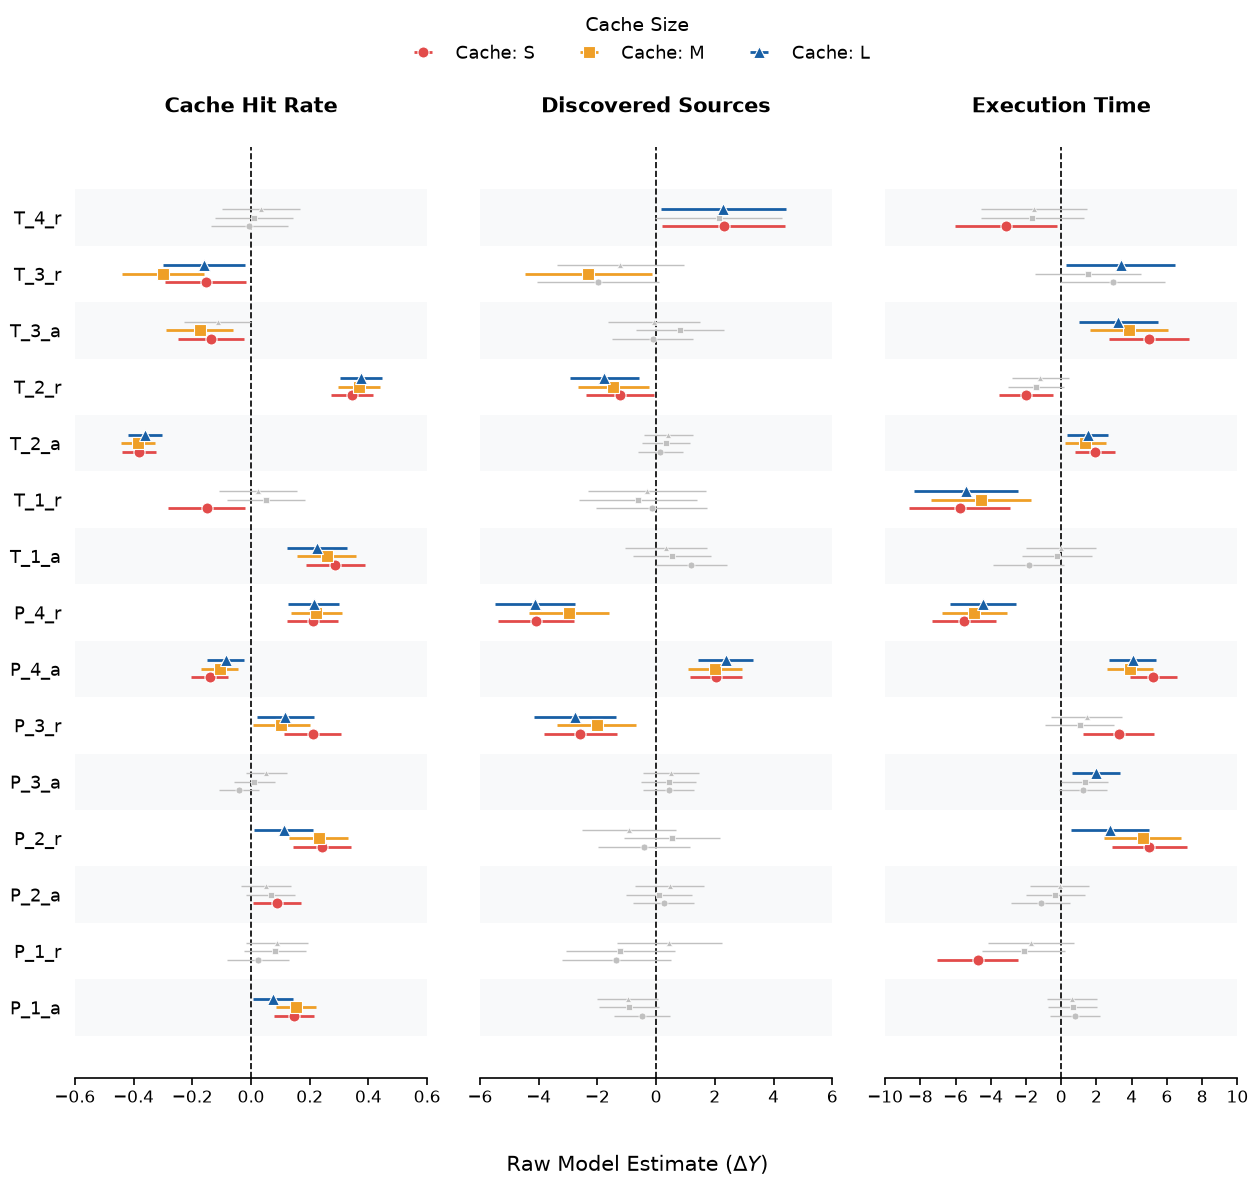

In [31]:
import os
import pandas as pd

def serialize_to_latex(all_models_dict, output_dir="../output/regression_analysis"):
    """
    Extracts fixed effects, standard errors, and p-values for all models.
    Serializes them into publication-ready LaTeX tables side-by-side (S, M, L).
    """
    os.makedirs(output_dir, exist_ok=True)

    # 1. Isolate the Baseline_Y coefficients for the specific diminishing returns table
    baseline_records = []

    # 2. Process all regression coefficients for the full summary tables
    for target, size_dict in all_models_dict.items():
        target_records = {}
        for size, result in size_dict.items():
            if result is None:
                continue

            size_key = size.upper()
            params = result.fe_params
            bse = result.bse
            pvals = result.pvalues

            for term in params.index:
                coef = params[term]
                se = bse[term]
                pval = pvals[term]

                # Append significance stars
                stars = ""
                if pval < 0.001: stars = "***"
                elif pval < 0.01: stars = "**"
                elif pval < 0.05: stars = "*"

                formatted_val = f"{coef:.3f}{stars} ({se:.3f})"

                # Store for full table
                if term not in target_records:
                    target_records[term] = {}
                target_records[term][size_key] = formatted_val

                # Store separately if it is the Baseline_Y term
                if term == 'Baseline_Y':
                    baseline_records.append({
                        "Target Metric": target,
                        "Cache Size": size_key,
                        "Coefficient (γ)": formatted_val
                    })

        # Generate LaTeX for the full target regression
        if target_records:
            df_target = pd.DataFrame.from_dict(target_records, orient='index')
            cols = [c for c in ['S', 'M', 'L'] if c in df_target.columns]
            df_target = df_target[cols].fillna("--")

            safe_target_name = target.replace(" ", "_").lower()
            latex_path = os.path.join(output_dir, f"full_regression_{safe_target_name}.tex")

            # Use standard LaTeX formatting
            latex_str = df_target.to_latex(
                caption=f"Fixed Effects for {target}. Standard errors in parentheses.",
                label=f"tab:full_{safe_target_name}",
                column_format="l" + "c" * len(cols),
                escape=False
            )

            with open(latex_path, "w") as f:
                f.write("% Require \\usepackage{booktabs} in preamble\n")
                f.write(latex_str)
            print(f"Saved full {target} table to: {latex_path}")

    # Generate LaTeX for the isolated Baseline_Y table
    df_baseline = pd.DataFrame(baseline_records)
    df_pivot = df_baseline.pivot(index="Target Metric", columns="Cache Size", values="Coefficient (γ)")
    cols = [c for c in ['S', 'M', 'L'] if c in df_pivot.columns]
    df_pivot = df_pivot[cols]

    baseline_path = os.path.join(output_dir, "baseline_coefficients.tex")
    baseline_latex_str = df_pivot.to_latex(
        caption="Autoregressive Penalty ($\\gamma$) by Target Metric and Cache Size.",
        label="tab:baseline_coefficients",
        column_format="l c c c",
        escape=False
    )

    with open(baseline_path, "w") as f:
        f.write("% Require \\usepackage{booktabs} in preamble\n")
        f.write(baseline_latex_str)
    print(f"Saved baseline summary table to: {baseline_path}")

    return df_pivot


if __name__ == "__main__":

    all_models = {
        'Cache Hit Rate': {},
        'Discovered Sources': {},
        'Execution Time': {}
    }

    # Dictionary to track the empirical baseline hit rates
    baseline_hr_averages = {}

    for size in ['s', 'm', 'l']:
        size_key = size.upper()

        topologies = read_topologies(
            "../data/refinement/out-queries",
            f"../data/refinement/output-topology-tracking-refinement-{size}",
        )

        df_hr, df_t, df_src = build_regression_observations(
            f'../data/refinement/query-results-raw-refinement-{size}.json',
            refinements_mapping,
            topologies
        )

        # Calculate and store the average unrefined hit rate for this cache size
        baseline_hr_averages[size_key] = df_hr['Baseline_Y'].mean()

        df_hr_std = df_hr
        df_src_std = df_src
        df_t_std = df_t

        print(f"\n[1/3] Fitting Cache Hit Rate Model ({size_key})")
        result_hit_rate, df_model_hr = run_mixed_effects_model(df_hr_std, alpha=0, include_interactions=False)
        if result_hit_rate is not None:
            metrics_hr = evaluate_mixed_model(result_hit_rate, df_model_hr, target_col="Delta_Y")
            all_models['Cache Hit Rate'][size_key] = result_hit_rate

        print(f"\n[2/3] Fitting Discovered Sources Model ({size_key})")
        result_sources, df_model_src = run_mixed_effects_model(df_src_std, alpha=0)
        if result_sources is not None:
            metrics_src = evaluate_mixed_model(result_sources, df_model_src, target_col="Delta_Y")
            all_models['Discovered Sources'][size_key] = result_sources

        print(f"\n[3/3] Fitting Execution Time Model ({size_key})")
        result_time, df_model_t = run_mixed_effects_model(df_t_std, alpha=0)
        if result_time is not None:
            metrics_t = evaluate_mixed_model(result_time, df_model_t, target_col="Delta_Y")
            all_models['Execution Time'][size_key] = result_time

    # Export all results strictly to LaTeX files
    print("\n" + "="*50)
    print("=== Exporting LaTeX Summaries ===")
    print("="*50)
    df_base_table = serialize_to_latex(all_models)

    # Export and print the empirical baseline averages
    df_averages = pd.DataFrame(list(baseline_hr_averages.items()), columns=['Cache Size', 'Average Baseline Hit Rate'])
    print("\n=== Empirical Average Baseline Cache Hit Rates ===")
    print(df_averages.to_string(index=False))

    avg_path = os.path.join("../output/regression_analysis", "empirical_baseline_averages.tex")
    with open(avg_path, "w") as f:
        f.write("% Require \\usepackage{booktabs} in preamble\n")
        f.write(df_averages.to_latex(index=False, caption="Empirical Average Baseline Cache Hit Rates prior to structural refinement.", label="tab:baseline_averages", escape=False))
    print(f"Saved empirical baseline averages to: {avg_path}")

    # Generate the final Faceted Forest Plot
    plot_faceted_forest(all_models, title="Significant Fixed Effects by Target and Cache Size")